In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import make_moons

# 1. Crear datos de prueba (No lineales, en forma de medias lunas)
X, Y = make_moons(n_samples=300, noise=0.15, random_state=42)

In [11]:
# 2. Definir y entrenar el MODELO SIMPLE
# Nota: Usamos keras.Input(shape) para evitar el UserWarning
model_simple = keras.Sequential([
    keras.Input(shape=(2,)), 
    layers.Dense(1, activation='sigmoid')
])

model_simple.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Entrenando Modelo Simple...")
model_simple.fit(X, Y, epochs=100, verbose=0) 

Entrenando Modelo Simple...


In [12]:
# 3. Definir y entrenar el MODELO PROFUNDO
# Este tiene capas ocultas para poder resolver el problema no lineal
model_deep = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("Entrenando Modelo Profundo...")
model_deep.fit(X, Y, epochs=100, verbose=0)

Entrenando Modelo Profundo...


In [13]:
# 4. Función para graficar la frontera de decisión (Tu código)
def plot_decision_boundary(model, X, Y, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    # Realizar predicciones sobre la rejilla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)
    
    # Dibujar contorno y puntos
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)

Generando gráficos...


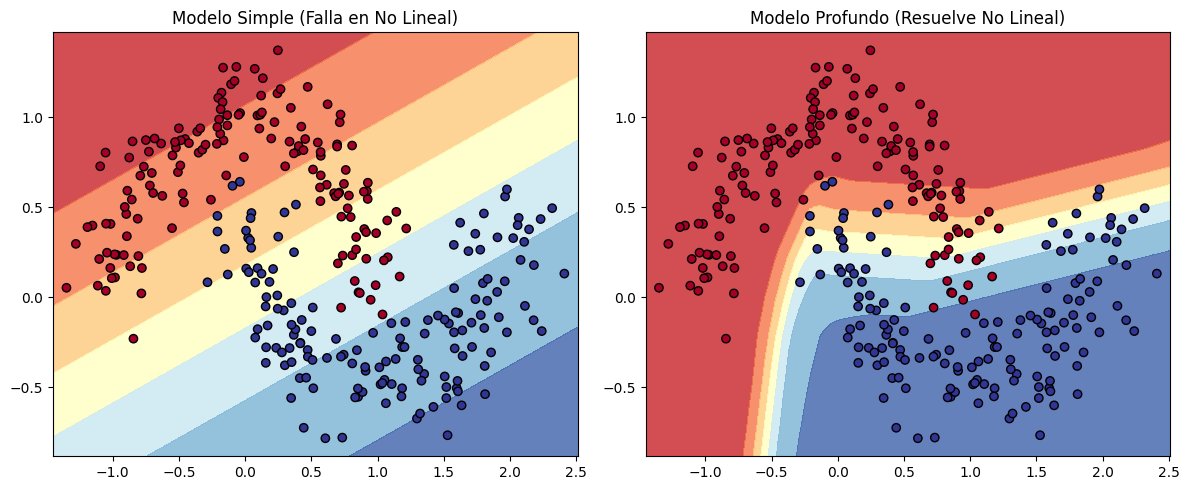

In [14]:
# 5. Visualización Final
print("Generando gráficos...")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(model_simple, X, Y, "Modelo Simple (Falla en No Lineal)")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_deep, X, Y, "Modelo Profundo (Resuelve No Lineal)")

plt.tight_layout() # Asegura que los gráficos no se superpongan
plt.show()